In [5]:
from utils import get_final_word, get_prefix

print("Hola" + get_final_word("El Pereira Rossell es un hospital."))
print(get_prefix("El Pereira Rossell es un hospital."))

Hola hospital
El Pereira Rossell es un


In [6]:
import pandas as pd 
import json

with open("QuUANTO_unified_final.json", "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data["assertions"])
sent = df["assertion"]
final_words = [get_final_word(s) for s in sent]
prefixs = [get_prefix(s) for s in sent]

df["input"] = prefixs
df["goal"] = final_words
df = df.drop(columns=["id"])

df.head()

,quales_id,quales_split,assertion,input,goal
0,10,dev_gold,El Pereira Rossell es un hospital.,El Pereira Rossell es un,hospital
1,100,dev_gold,El sector de alojamiento y servicios de comida...,El sector de alojamiento y servicios de comida...,desempleo
2,103,dev_gold,"Históricamente, el 60% de las empresas del sec...","Históricamente, el 60% de las empresas del sec...",desempleo
3,108,dev_gold,Las escuelas privadas no tenían una posible fe...,Las escuelas privadas no tenían una posible fe...,régimen
4,114,dev_gold,"La plataforma CREA, de Plan Ceibal, fue una he...","La plataforma CREA, de Plan Ceibal, fue una he...",virtual


In [7]:
df.to_csv('final_dataset.csv')

In [8]:
from pathlib import Path
import gc
import json
import math
import re
import sys

import pandas as pd
import torch
import torch.nn.functional as F
from tokenizers import Tokenizer
from tqdm.auto import tqdm


# ---------------------------------------------------------------------
# Rutas
# Ejecutar desde evaluación/ o desde la raíz del repositorio.
# ---------------------------------------------------------------------

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "final_dataset.csv").exists():
    EVALUATION_DIR = CURRENT_DIR
elif (CURRENT_DIR / "evaluación" / "final_dataset.csv").exists():
    EVALUATION_DIR = CURRENT_DIR / "evaluación"
else:
    raise FileNotFoundError("No se encontró evaluación/final_dataset.csv")

REPOSITORY_DIR = EVALUATION_DIR.parent
sys.path.insert(0, str(REPOSITORY_DIR))

from model import GPT, GPTConfig


MODEL_DIRECTORIES = {
    "charruaLLM": EVALUATION_DIR / "charruaLLM",
    "spanishLLM": EVALUATION_DIR / "spanishLLM",
}

DATASET_PATH = EVALUATION_DIR / "final_dataset.csv"
EXACT_OUTPUT_PATH = EVALUATION_DIR / "exact_matching_results.csv"
NLL_OUTPUT_PATH = EVALUATION_DIR / "nll_results.csv"

MAX_PREDICTION_TOKENS = 32


# ---------------------------------------------------------------------
# Dispositivo
# ---------------------------------------------------------------------

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.set_float32_matmul_precision("high")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Dispositivo: {DEVICE}")


# ---------------------------------------------------------------------
# Carga del modelo
# ---------------------------------------------------------------------

def load_model(model_directory):
    checkpoint_path = model_directory / "best.pt"
    tokenizer_path = model_directory / "tokenizer.json"

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
        mmap=True,
    )

    config = GPTConfig(**checkpoint["cfg"])
    model = GPT(config)

    state_dict = {
        key.replace("_orig_mod.", ""): value
        for key, value in checkpoint["model"].items()
    }

    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()

    tokenizer = Tokenizer.from_file(str(tokenizer_path))

    del checkpoint, state_dict
    gc.collect()

    return model, tokenizer


# ---------------------------------------------------------------------
# Normalización usada por el dataset:
# quita espacios y el punto final, pero mantiene mayúsculas y acentos.
# ---------------------------------------------------------------------

def normalize_word(text):
    text = str(text).strip()

    if not text:
        return ""

    first_word = text.split(maxsplit=1)[0]

    if first_word.endswith("."):
        first_word = first_word[:-1]

    return first_word


# ---------------------------------------------------------------------
# Exact matching
#
# Generación greedy autoregresiva. No usa la longitud de la palabra
# objetivo. Se detiene cuando aparece el comienzo de otra palabra,
# EOS o MAX_PREDICTION_TOKENS.
# ---------------------------------------------------------------------

WORD_BOUNDARY = re.compile(r"\S\s")


@torch.inference_mode()
def predict_next_word(model, tokenizer, prefix):
    prefix_ids = tokenizer.encode(str(prefix)).ids

    eos_id = tokenizer.token_to_id("<|endoftext|>")

    if not prefix_ids:
        prefix_ids = [eos_id if eos_id is not None else 0]

    history = list(prefix_ids)
    predicted_ids = []
    truncated = True

    for _ in range(MAX_PREDICTION_TOKENS):
        context_ids = history[-model.cfg.block_size:]

        x = torch.tensor(
            [context_ids],
            dtype=torch.long,
            device=DEVICE,
        )

        logits, _ = model(x)
        next_id = int(torch.argmax(logits[0, -1]).item())

        if eos_id is not None and next_id == eos_id:
            truncated = False
            break

        candidate_ids = predicted_ids + [next_id]
        candidate_text = tokenizer.decode(
            candidate_ids,
            skip_special_tokens=False,
        )

        # El token nuevo comienza otra palabra.
        if WORD_BOUNDARY.search(candidate_text):
            truncated = False
            break

        predicted_ids.append(next_id)
        history.append(next_id)

    raw_prediction = tokenizer.decode(
        predicted_ids,
        skip_special_tokens=False,
    )

    predicted_word = normalize_word(raw_prediction)

    return {
        "predicted_word": predicted_word,
        "raw_prediction": raw_prediction,
        "predicted_token_ids": predicted_ids,
        "prediction_truncated": truncated,
    }


# ---------------------------------------------------------------------
# NLL de la palabra objetivo
#
# Se usa teacher forcing:
# P(t1 | contexto) * P(t2 | contexto, t1) * ...
#
# log_softmax es la versión numéricamente estable de log(softmax).
# ---------------------------------------------------------------------

@torch.inference_mode()
def calculate_target_nll(model, tokenizer, prefix, goal):
    prefix_ids = tokenizer.encode(str(prefix)).ids
    target_ids = tokenizer.encode(str(goal)).ids

    if not target_ids:
        raise ValueError(f"La palabra objetivo no produjo tokens: {goal!r}")

    if not prefix_ids:
        eos_id = tokenizer.token_to_id("<|endoftext|>")
        prefix_ids = [eos_id if eos_id is not None else 0]

    full_ids = prefix_ids + target_ids

    if len(full_ids) - 1 <= model.cfg.block_size:
        x = torch.tensor(
            [full_ids[:-1]],
            dtype=torch.long,
            device=DEVICE,
        )

        logits, _ = model(x)

        start_position = len(prefix_ids) - 1
        end_position = start_position + len(target_ids)

        target_logits = logits[0, start_position:end_position].float()
        target_tensor = torch.tensor(
            target_ids,
            dtype=torch.long,
            device=DEVICE,
        )

        target_log_probabilities = F.log_softmax(
            target_logits,
            dim=-1,
        ).gather(
            dim=-1,
            index=target_tensor.unsqueeze(-1),
        ).squeeze(-1)

        log_probabilities = target_log_probabilities.cpu().tolist()

    else:
        # Fallback para contextos mayores que block_size.
        history = list(prefix_ids)
        log_probabilities = []

        for target_id in target_ids:
            context_ids = history[-model.cfg.block_size:]

            x = torch.tensor(
                [context_ids],
                dtype=torch.long,
                device=DEVICE,
            )

            logits, _ = model(x)
            next_token_log_probs = F.log_softmax(
                logits[0, -1].float(),
                dim=-1,
            )

            log_probabilities.append(
                float(next_token_log_probs[target_id].item())
            )

            history.append(target_id)

    token_details = []

    for position, (token_id, log_probability) in enumerate(
        zip(target_ids, log_probabilities)
    ):
        token_details.append(
            {
                "position": position,
                "token_id": token_id,
                "token": tokenizer.id_to_token(token_id),
                "probability": math.exp(log_probability),
                "nll": -log_probability,
            }
        )

    nll_sum = -sum(log_probabilities)
    nll_mean = nll_sum / len(target_ids)

    return {
        "target_token_count": len(target_ids),
        "target_token_ids": target_ids,
        "target_token_details": token_details,
        "nll_sum": nll_sum,
        "nll_mean": nll_mean,
        "target_word_probability": math.exp(-nll_sum),
        "geometric_mean_token_probability": math.exp(-nll_mean),
        "token_perplexity": math.exp(nll_mean),
    }


# ---------------------------------------------------------------------
# Evaluación
# ---------------------------------------------------------------------

dataset = pd.read_csv(
    DATASET_PATH,
    keep_default_na=False,
)

required_columns = {"input", "goal"}
missing_columns = required_columns - set(dataset.columns)

if missing_columns:
    raise ValueError(
        f"Faltan columnas en final_dataset.csv: {sorted(missing_columns)}"
    )

exact_results = []
nll_results = []

for model_name, model_directory in MODEL_DIRECTORIES.items():
    print(f"\nEvaluando {model_name}...")

    model, tokenizer = load_model(model_directory)

    for _, row in tqdm(
        dataset.iterrows(),
        total=len(dataset),
        desc=model_name,
    ):
        prefix = row["input"]
        goal = row["goal"]
        target_word = normalize_word(goal)

        prediction = predict_next_word(
            model=model,
            tokenizer=tokenizer,
            prefix=prefix,
        )

        nll = calculate_target_nll(
            model=model,
            tokenizer=tokenizer,
            prefix=prefix,
            goal=goal,
        )

        original_data = row.to_dict()

        exact_results.append(
            {
                "model": model_name,
                **original_data,
                "target_word": target_word,
                "predicted_word": prediction["predicted_word"],
                "exact_match": prediction["predicted_word"] == target_word,
                "raw_prediction": prediction["raw_prediction"],
                "predicted_token_ids": json.dumps(
                    prediction["predicted_token_ids"]
                ),
                "prediction_truncated": prediction["prediction_truncated"],
            }
        )

        nll_results.append(
            {
                "model": model_name,
                **original_data,
                "target_word": target_word,
                "predicted_word": prediction["predicted_word"],
                "target_token_count": nll["target_token_count"],
                "target_token_ids": json.dumps(nll["target_token_ids"]),
                "target_token_details": json.dumps(
                    nll["target_token_details"],
                    ensure_ascii=False,
                ),
                "nll_sum": nll["nll_sum"],
                "nll_mean": nll["nll_mean"],
                "target_word_probability": nll[
                    "target_word_probability"
                ],
                "geometric_mean_token_probability": nll[
                    "geometric_mean_token_probability"
                ],
                "token_perplexity": nll["token_perplexity"],
            }
        )

    del model, tokenizer
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()


# ---------------------------------------------------------------------
# Guardado de resultados
# ---------------------------------------------------------------------

exact_df = pd.DataFrame(exact_results)
nll_df = pd.DataFrame(nll_results)

exact_df.to_csv(
    EXACT_OUTPUT_PATH,
    index=False,
    encoding="utf-8",
)

nll_df.to_csv(
    NLL_OUTPUT_PATH,
    index=False,
    encoding="utf-8",
)

print(f"\nExact matching guardado en: {EXACT_OUTPUT_PATH}")
print(f"NLL guardado en: {NLL_OUTPUT_PATH}")


# ---------------------------------------------------------------------
# Resumen
# ---------------------------------------------------------------------

exact_summary = (
    exact_df.groupby("model")["exact_match"]
    .agg(correct_predictions="sum", total_examples="count", accuracy="mean")
    .reset_index()
)

nll_summary_rows = []

for model_name, group in nll_df.groupby("model"):
    corpus_token_nll = (
        group["nll_sum"].sum()
        / group["target_token_count"].sum()
    )

    nll_summary_rows.append(
        {
            "model": model_name,
            "mean_word_nll": group["nll_sum"].mean(),
            "corpus_token_nll": corpus_token_nll,
            "token_perplexity": math.exp(corpus_token_nll),
            "mean_target_word_probability": group[
                "target_word_probability"
            ].mean(),
        }
    )

nll_summary = pd.DataFrame(nll_summary_rows)

print("\nExact matching:")
display(exact_summary)

print("\nNLL:")
display(nll_summary)

/Users/jpconde/Facultad/charruaLLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: mps

Evaluando charruaLLM...


charruaLLM: 100%|██████████| 834/834 [00:08<00:00, 102.66it/s]



Evaluando spanishLLM...


spanishLLM: 100%|██████████| 834/834 [00:08<00:00, 100.42it/s]



Exact matching guardado en: /Users/jpconde/Facultad/charruaLLM/evaluación/exact_matching_results.csv
NLL guardado en: /Users/jpconde/Facultad/charruaLLM/evaluación/nll_results.csv

Exact matching:


,model,correct_predictions,total_examples,accuracy
0,charruaLLM,222,834,0.266187
1,spanishLLM,39,834,0.046763



NLL:


,model,mean_word_nll,corpus_token_nll,token_perplexity,mean_target_word_probability
0,charruaLLM,4.139642,2.353416,10.521453,0.250610
1,spanishLLM,22.814341,7.452864,1724.795133,0.029974


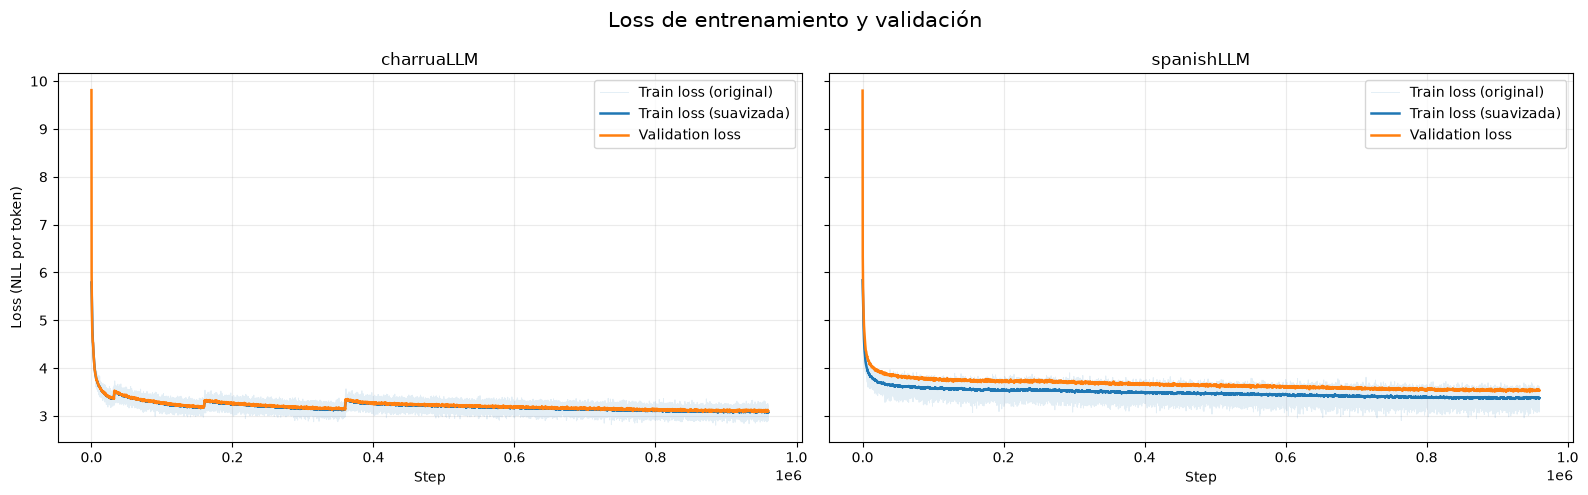

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "charruaLLM").exists():
    EVALUATION_DIR = CURRENT_DIR
else:
    EVALUATION_DIR = CURRENT_DIR / "evaluación"


MODEL_DIRECTORIES = {
    "charruaLLM": EVALUATION_DIR / "charruaLLM",
    "spanishLLM": EVALUATION_DIR / "spanishLLM",
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5),
    sharey=True,
)

for axis, (model_name, model_directory) in zip(
    axes,
    MODEL_DIRECTORIES.items(),
):
    losses = pd.read_csv(model_directory / "losses.csv")

    # Loss calculada durante el entrenamiento.
    train_loss = losses[
        (losses["split"] == "train")
        & (losses["kind"] == "train")
    ].copy()

    # Loss de validación calculada durante las evaluaciones.
    validation_loss = losses[
        (losses["split"] == "val")
        & (losses["kind"] == "eval")
    ].copy()

    # Suavizado de la loss de entrenamiento para facilitar la lectura.
    smoothing_window = max(1, min(200, len(train_loss) // 20))

    train_loss["smoothed_loss"] = (
        train_loss["loss"]
        .rolling(
            window=smoothing_window,
            min_periods=1,
            center=True,
        )
        .mean()
    )

    axis.plot(
        train_loss["step"],
        train_loss["loss"],
        color="tab:blue",
        alpha=0.12,
        linewidth=0.7,
        label="Train loss (original)",
    )

    axis.plot(
        train_loss["step"],
        train_loss["smoothed_loss"],
        color="tab:blue",
        linewidth=1.8,
        label="Train loss (suavizada)",
    )

    axis.plot(
        validation_loss["step"],
        validation_loss["loss"],
        color="tab:orange",
        linewidth=1.8,
        label="Validation loss",
    )

    axis.set_title(model_name)
    axis.set_xlabel("Step")
    axis.grid(alpha=0.25)
    axis.legend()

axes[0].set_ylabel("Loss (NLL por token)")

fig.suptitle(
    "Loss de entrenamiento y validación",
    fontsize=15,
)

plt.tight_layout()
plt.show()